In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os

_, name = os.path.split(os.getcwd())
if name=="notebooks":
    os.chdir("../.")

# Load data

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl

from traffic_models.experiment.probe_data import prepare_probe_experiment_data
from traffic_models.experiment.probe_experiment import DatasetConfig, ProbeExperimentConfig
from traffic_models.data.mobile_century_mapped import mobile_century_ramp_indexes

conf = ProbeExperimentConfig(
    dt_seconds=1,
    dx_meters=30,
    data = DatasetConfig(
        name="us-101",
        start_seconds=180,  # start 3 minutes after the beginning
        end_seconds=2700,
        # start_seconds=750,  # zooming
        # end_seconds=1000,  # 
        probe_fraction=0.02,
        boundary_fraction=0.0,
        smoothing=False
    )
# I80 is cut into three 15-minute periods: 4:00 p.m. to 4:15 p.m.; 5:00 p.m. to 5:15 p.m.; and 5:15 p.m. to 5:30 p.m
#     data=DatasetConfig(
#         name = "i-80",
#         start_seconds = 3780, #5:03 PM
#         end_seconds = 5400, #5:30 PM
#         boundary_fraction=0.0,
#         probe_fraction=0.1,
#         smoothing=False
# )
)

conf = ProbeExperimentConfig(
    dt_seconds=5,
    dx_meters=200,
    seed=1,
    # dt_seconds=5,
    # dx_meters=200,
    data=DatasetConfig(
        name="mobile-century",
        path="data/mobilecentury/NB_veh_files",
        probe_fraction=0.1,
        boundary_fraction=1.0,
        start_seconds=1_600, end_seconds=32_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=1_600, end_seconds=32_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=18_000, end_seconds=24_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=30_000, end_seconds=30_400, xmin_meters=34_000, xmax_meters=40_000,
        smoothing=True,
    ),
)

conf.kalman.velocity_model_variance=0.1
grid, discretized_trajectories, full_trajectories, fields = prepare_probe_experiment_data(conf)
measured_v = np.zeros((grid.n_timesteps, grid.n_cells)) * np.nan
measured_v[discretized_trajectories["t_index"], discretized_trajectories["x_index"]] = (
    discretized_trajectories["velocity"]
)

if conf.data.name=="mobile-century":
    on_ramps_index, off_ramps_index = mobile_century_ramp_indexes(grid, conf.data.xmin_meters)
else:
    on_ramps_index, off_ramps_index = np.empty(0,dtype=int), np.empty(0,dtype=int)

c:\Users\a055963\git\traffic-smoothing\.venv\Lib\site-packages\osmnx\convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


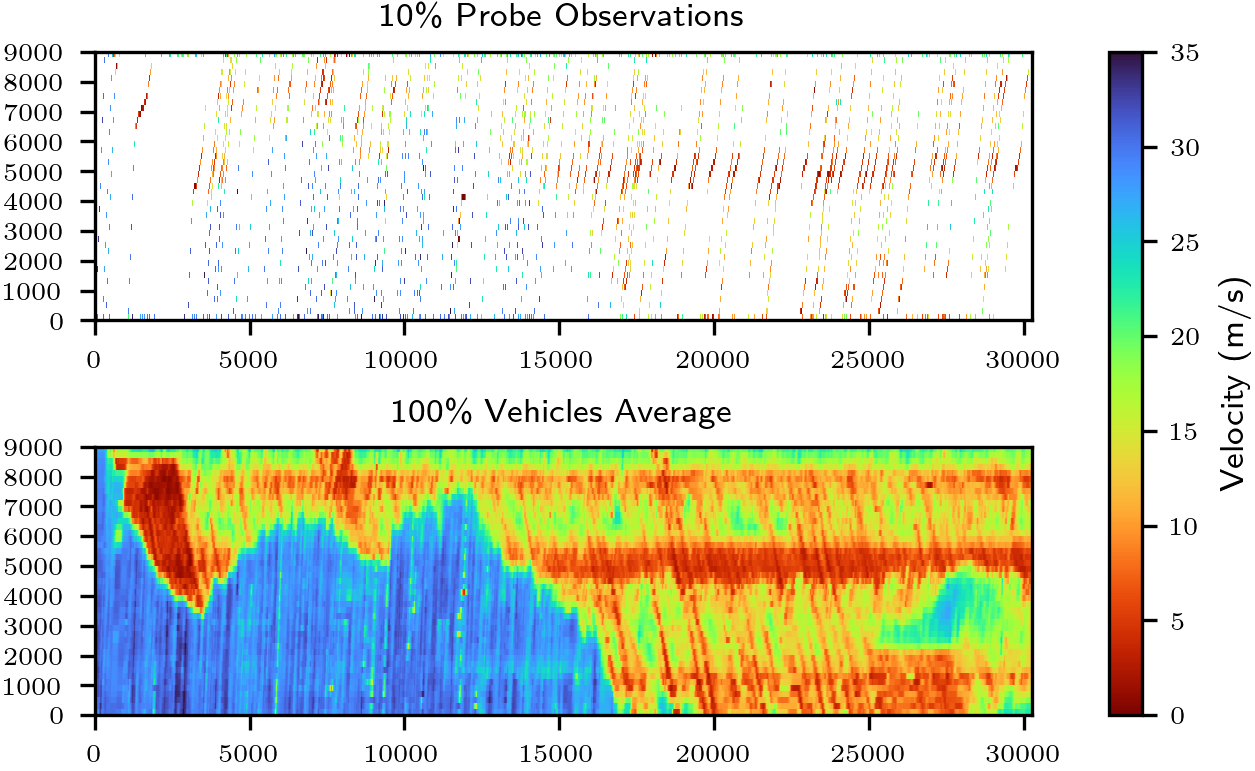

In [15]:
from traffic_models.plot.utils import rcparams
plt.rcParams.update(rcparams(
    beamer=True,
))
fig, axes = plt.subplots(2,1)
_ = axes[0].matshow(measured_v.T, aspect="auto", origin="lower",cmap="turbo_r", extent=[0, grid.n_timesteps*conf.dt_seconds, 0, grid.n_cells*conf.dx_meters],vmin=0, vmax=35)
ms = axes[1].matshow(fields.speed.T, aspect="auto", origin="lower",cmap="turbo_r", extent=[0, grid.n_timesteps*conf.dt_seconds, 0, grid.n_cells*conf.dx_meters],vmin=0, vmax=35)
fig.colorbar(ms, ax=[axes[0],axes[1]],label="Velocity (m/s)")
axes[0].set_title(f"{conf.data.probe_fraction*100:.0f}"+r"\% Probe Observations")
axes[1].set_title(r"100\% Vehicles Average")
for ax in axes:
    ax.xaxis.set_ticks_position("bottom")
fig.set_dpi(300)
# axes[0].colorbar(label="Speed (m/s)")

# Adaptive Smoothing

ASM rmse on trajectories: 17.59 kmph


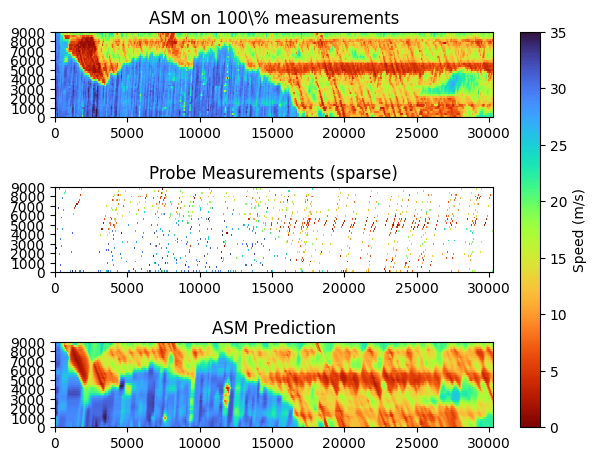

In [17]:
import torch
from traffic_models.dense_fields import make_anisotropic_kernel
from traffic_models.metrics import trajectory_mse
from traffic_models.nn.asm import AdaptiveSmoothing

plt.rcdefaults()
sigma_x_meters = 200.0 if conf.data.name=="mobile-century" else 100.0
sigma_t_seconds = 60.0 if conf.data.name=="mobile-century" else 5.0

kernel_space_window = 100*sigma_x_meters
kernel_time_window = 100*sigma_t_seconds
asm_model = AdaptiveSmoothing(
    kernel_time_window=kernel_time_window,
    kernel_space_window=kernel_space_window,
    dx=grid.dx_meters,
    dt=grid.dt_seconds,
    init_delta=sigma_x_meters,
    init_tau=sigma_t_seconds,
)
asm_model.eval()
measured_v_torch = torch.from_numpy(measured_v).float().unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
asm_pred_torch = asm_model(measured_v_torch)
v_asm = asm_pred_torch.detach().numpy().squeeze(0)
fig, axes = plt.subplots(3, 1)
kwargs = dict(
    aspect="auto",
    origin="lower",
    cmap="turbo_r",
    vmin=0,
    vmax=35,
    extent=[0, grid.n_timesteps * grid.dt_seconds, 0, grid.n_cells * grid.dx_meters],
)
axes[0].matshow(fields.speed.T, **kwargs)
axes[0].set_title(r"ASM on 100\% measurements")
axes[1].matshow(measured_v.T, **kwargs)
axes[1].set_title("Probe Measurements (sparse)")
axes[2].matshow(v_asm.T, **kwargs)
axes[2].set_title("ASM Prediction")
mse = trajectory_mse(full_trajectories, v_asm)
print(f"ASM rmse on trajectories: {mse**0.5*3.6:.2f} kmph")
plt.tight_layout()
for ax in axes:
    ax.xaxis.set_ticks_position("bottom")
plt.colorbar(axes[0].images[0], ax=axes, label="Speed (m/s)");

In [18]:
INIT_MODEL_VARIANCE = np.nanvar(fields.speed)
VELOCITY_MODEL_VARIANCE = conf.kalman.velocity_model_variance
VELOCITY_MEASURE_VARIANCE = np.nanvar(measured_v - fields.speed).item()

# Naive Physics Rollout

c:\Users\a055963\git\traffic-smoothing\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\a055963\git\traffic-smoothing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


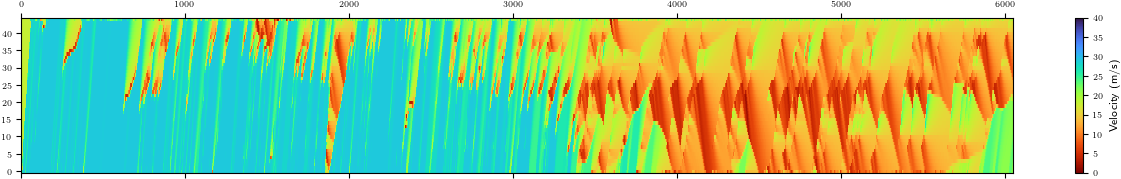

In [11]:
from traffic_models.flows import ARZFlow, PowerLawFlux, ZeroFlow, CongestedFlow
from traffic_models.flows_default import greenshields_mobile_century_herrera_bayen_2010, triangular_mobile_century_herrera_bayen_2010
from traffic_models.naive_physics import naive_physics_on_trajectories

# flow = ARZFlow(PowerLawFlux(v_max=40, rho_max=0.15, gamma=1.0))
flow = greenshields_mobile_century_herrera_bayen_2010()
# flow = triangular_mobile_century_herrera_bayen_2010()
# flow = CongestedFlow(v_max=30, rho_max=0.15)
v_0 = np.ones(grid.n_cells) * np.nanmean(fields.speed)
v_init = naive_physics_on_trajectories(
    discretized_trajectories, v_0, flow, grid, trust_ratio=0.5
).v_hat
plt.matshow(v_init.T, aspect="auto", origin="lower", cmap="turbo_r", vmin=0, vmax=40)
plt.colorbar(label="Velocity (m/s)")

# 4DVar

In [19]:
import torch
from traffic_models.flows import CongestedFlow, DelCastilloBenitezFlux, GreenshieldsFlow, PiecewiseQuadraticFlow, PowerLawFlux, QuadraticLinearFlow
from traffic_models.metrics import trajectory_mse
from traffic_models.sim import RampConfig
from traffic_models.var_optim import FourDVarConfig, windowed_w4DVAR
# with torch.autograd.set_detect_anomaly(True):
if conf.data.name in ("i-80", "us-101"):
    flow = ARZFlow(PiecewiseQuadraticFlow(v_max=40, rho_max=0.22, rho_c=0.03, Q_max=0.8))
elif conf.data.name=="mobile-century":
    # flow = ARZFlow(PowerLawFlux(v_max=40, rho_max=0.15, gamma=1.0))
    # flow = GreenshieldsFlow(v_max=35, rho_max=0.15)
    # flow = greenshields_mobile_century_herrera_bayen_2010()
    # flow = triangular_mobile_century_herrera_bayen_2010()
    # flow = PiecewiseQuadraticFlow(v_max=40, rho_max=0.22, rho_c=0.05, Q_max=1.3)
    flow = ARZFlow(PiecewiseQuadraticFlow(v_max=40, rho_max=0.1, rho_c=0.02, Q_max=0.6),tau=5.0)
    # flow = QuadraticLinearFlow(v_max=40, rho_max=0.22, rho_c=0.05)
    # flow = ARZFlow(QuadraticLinearFlow(v_max=40, rho_max=0.1, rho_c=0.033))
else:
    raise ValueError(f"Unknown dataset {conf.data.name}")

result = windowed_w4DVAR(
    trajectories=discretized_trajectories,
    v_0 = np.ones(grid.n_cells)*np.nanmean(fields.speed),
    conf=FourDVarConfig(
        background_variance=INIT_MODEL_VARIANCE, # type: ignore
        model_variance=0.01, # tuned so the costs are balanced (this is a hyperparameter)
        measurement_variance=VELOCITY_MEASURE_VARIANCE,
        n_iters=500,
        solver="rusanov" if isinstance(flow, ARZFlow) else "godunov",
    ),
    grid=grid,
    flow=flow,
    window_seconds=np.ceil((grid.n_timesteps*grid.dt_seconds)),
    ramp_config=RampConfig(
        # on_ramps_index=np.empty(0, dtype=int),
        # off_ramps_index=np.empty(0, dtype=int),
        on_ramps_index=on_ramps_index,
        off_ramps_index=off_ramps_index,
        ),
    learn_flow=True,
    device="cuda" if torch.cuda.is_available() else "cpu",
    init="naive_smoothing",
    forecast=False,
)
v_smooth_4dvar, v_pred_4dvar, history, torch_flow, rho_hat = result.velocity_hat, result.velocity_pred, result.history, result.flow, result.rho_hat
mse = trajectory_mse(full_trajectories, v_smooth_4dvar)
print(f"4D-Var RMSE: {mse**0.5*3.6:.2f} kmph")

4D-Var RMSE: 15.37 kmph


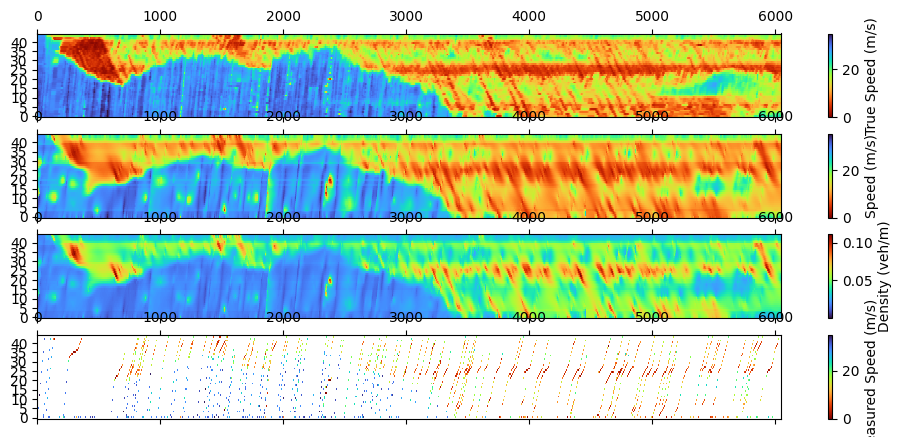

In [20]:
plt.rcdefaults()
fig, axes = plt.subplots(4, 1, figsize=(12, 5))
ms = axes[0].matshow(fields.speed.T, aspect="auto", origin="lower",cmap="turbo_r", vmin=0, vmax=35)
plt.colorbar(ms, label="True Speed (m/s)", ax=axes[0])
ms = axes[1].matshow(v_smooth_4dvar.T, aspect="auto", origin="lower",cmap="turbo_r", vmin=0, vmax=35)
plt.colorbar(ms, label="Speed (m/s)", ax=axes[1])
if isinstance(flow, ARZFlow):
    ms = axes[2].matshow(rho_hat.T, aspect="auto", origin="lower",cmap="turbo")
plt.colorbar(ms, label="Density (veh/m)", ax=axes[2])
ms = axes[3].matshow(measured_v.T, aspect="auto", origin="lower",cmap="turbo_r", vmin=0, vmax=35)
plt.colorbar(ms, label="Measured Speed (m/s)", ax=axes[3]);


In [21]:
import plotly.express as px
import seaborn as sns
# sns.lineplot(history[0], x="step", y)
window = 0
columns = history[window].history.columns
param_history = history[window].history.select(
    "loss",
    "measurement_cost",
    "model_cost",
    "background_cost",
   **{name.removeprefix("log_"): pl.col(name).exp() for name in columns if name.startswith("log_")},
)
fig = px.line(param_history)
fig.update_yaxes(type="log")
fig.show()

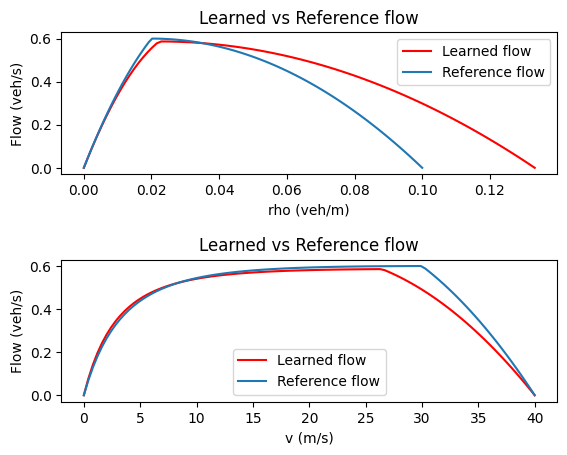

In [22]:

from traffic_models.flows import GreenshieldsFlow, QuadraticLinearFlow, PiecewiseQuadraticFlow, TriangularFlow
plt.rcdefaults()

def plot_flow(
    flow: callable,
    reference_flow: TriangularFlow,
) -> plt.Figure:
    """
    Plot the learned flow against the reference flow.
    """
    fig, axes = plt.subplots(2,1)
    ax = axes[0]
    rho_lin = np.linspace(0, flow.rho_max, 100)
    Q_model = flow(rho_lin)
    ax.plot(rho_lin, Q_model, color="r")

    rho_lin = np.linspace(0, reference_flow.rho_max, 100)
    Q_ref = reference_flow(rho_lin)
    ax.plot(rho_lin.reshape(-1), Q_ref.reshape(-1))
    # ax.scatter(rho_lin.reshape(-1), Q_ref.reshape(-1), alpha=0.01, marker="x")
    leg = ax.legend(["Learned flow", "Reference flow"])
    # for lh in leg.legend_handles:
    #     lh.set_alpha(1)
    # assert grid.dx_meters / grid.dt_seconds >= pred_v_max
    ax.set_xlabel("rho (veh/m)")
    ax.set_ylabel("Flow (veh/s)")
    ax.set_title("Learned vs Reference flow")

    if isinstance(flow, TriangularFlow):
        factor = 1.2
    else:
        factor = 1.0
    ax = axes[1]
    v_lin = np.linspace(0, flow.v_max*factor, 100)
    Q_model = flow(flow.density_from_velocity(v_lin))
    ax.plot(v_lin, Q_model, color="r")

    v_lin = np.linspace(0, reference_flow.v_max*factor, 100)
    Q_ref = reference_flow(reference_flow.density_from_velocity(v_lin))
    ax.plot(v_lin.reshape(-1), Q_ref.reshape(-1))
    # ax.scatter(v_lin.reshape(-1), Q_ref.reshape(-1), alpha=0.01, marker="x")
    leg = ax.legend(["Learned flow", "Reference flow"])
    # for lh in leg.legend_handles:
    #     lh.set_alpha(1)
    # assert grid.dx_meters / grid.dt_seconds >= pred_v_max
    ax.set_xlabel("v (m/s)")
    ax.set_ylabel("Flow (veh/s)")
    ax.set_title("Learned vs Reference flow")

    # plt.close(fig)
    fig.subplots_adjust(hspace=0.6)
    return fig


if isinstance(flow, TriangularFlow):
    rho_c = param_history[-1]["rho_c"].item()
    Q_c = param_history[-1]["Q_c"].item()
    rho_max = param_history[-1]["rho_max"].item()
    rho_free_flow = param_history[-1]["rho_free_flow"].item()
    learned_flow = TriangularFlow(rho_c, Q_c, rho_max, rho_free_flow=rho_free_flow)
    plot_flow(flow=learned_flow, reference_flow=flow)
elif isinstance(flow, GreenshieldsFlow):
    rho_max = param_history[-1]["rho_max"].item()
    v_max = param_history[-1]["v_max"].item()
    learned_flow = GreenshieldsFlow(v_max, rho_max)
    plot_flow(flow=learned_flow, reference_flow=flow)
elif isinstance(flow, PiecewiseQuadraticFlow):
    # v_max = param_history[-1]["v_max"].item()
    v_max = flow.v_max
    rho_max = param_history[-1]["rho_max"].item()
    rho_c = param_history[-1]["rho_c"].item()
    Q_max = param_history[-1]["Q_max"].item()
    learned_flux = PiecewiseQuadraticFlow(v_max, rho_max, rho_c, Q_max)
    plot_flow(flow=learned_flux, reference_flow=flow)
elif isinstance(flow, QuadraticLinearFlow):
    v_max = flow.v_max
    # v_max = param_history[-1]["v_max"].item()
    rho_c = param_history[-1]["rho_c"].item()
    rho_max = param_history[-1]["rho_max"].item()
    learned_flux = QuadraticLinearFlow(v_max, rho_max, rho_c)
    plot_flow(flow=learned_flux, reference_flow=flow)
elif isinstance(flow, ARZFlow):
    if isinstance(flow.flux_function, QuadraticLinearFlow):
        rho_c = param_history[-1]["rho_c"].item()
        rho_max = param_history[-1]["rho_max"].item()
        v_max = param_history[-1]["v_max"].item()
        learned_flux = QuadraticLinearFlow(v_max, rho_max, rho_c)
        plot_flow(flow=learned_flux, reference_flow=flow.flux_function)
    if isinstance(flow.flux_function, PowerLawFlux):
        # gamma = param_history[-1]["gamma"].item()
        gamma = 1.0
        rho_max = param_history[-1]["rho_max"].item()
        v_max = param_history[-1]["v_max"].item()
        learned_flux = PowerLawFlux(v_max, rho_max, gamma)
        plot_flow(flow=learned_flux, reference_flow=flow.flux_function)
    if isinstance(flow.flux_function, PiecewiseQuadraticFlow):
        # v_max = param_history[-1]["v_max"].item()
        v_max = flow.flux_function.v_max
        rho_max = param_history[-1]["rho_max"].item()
        rho_c = param_history[-1]["rho_c"].item()
        Q_max = param_history[-1]["Q_max"].item()
        learned_flux = PiecewiseQuadraticFlow(v_max, rho_max, rho_c, Q_max)
        plot_flow(flow=learned_flux, reference_flow=flow.flux_function)

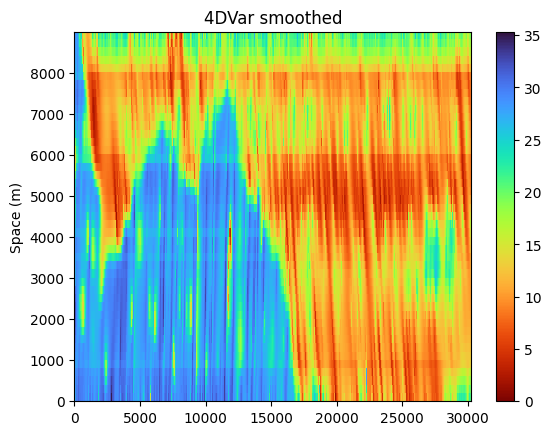

In [23]:
def _plot_4dvar_results():
    if len(history) > 1:
        fig, axes = plt.subplots(2, 1)
        ax = axes[0]
    else:
        fig, ax = plt.subplots()
    vmin = 0
    vmax = np.nanmax(fields.speed)
    sm0 = ax.matshow(
        v_smooth_4dvar.T,
        extent=(0, fields.tmax, 0, fields.xmax),
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="turbo_r"
    )
    ax.set_title("4DVar smoothed")
    ax.xaxis.set_ticks_position("bottom")
    ax.set_ylabel("Space (m)")
    fig.colorbar(sm0,ax=ax)

    if len(history) == 1:
        return
    sm1 = axes[1].matshow(
        v_pred_4dvar.T,
        extent=(0, fields.tmax, 0, fields.xmax),
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="turbo_r"
    )
    axes[1].set_title("4DVar predicted")
    axes[1].xaxis.set_ticks_position("bottom")
    axes[1].set_xlabel("Time (s)")
    fig.colorbar(sm1,ax=axes[1])

    axes[0].get_xaxis().set_visible(False)
_plot_4dvar_results()

In [24]:
ramp_param = "flux_ratio"
# ramp_param = "source_term"
n_ramps: int = (len(on_ramps_index) + len(off_ramps_index))
_param_history: pl.DataFrame = history[0].history.with_columns(
    [pl.col(ramp_param).list.get(i).alias(f"{ramp_param}_{i}") for i in range(n_ramps)]
).drop(ramp_param)
fig = px.line(_param_history, x="step", y=[f"{ramp_param}_{i}" for i in range(n_ramps)], color_discrete_sequence=px.colors.sequential.Turbo[-n_ramps:])
fig.update_yaxes(type="linear")
fig.show()

# Naive physics

In [25]:
from traffic_models.naive_physics import naive_physics_on_trajectories
from traffic_models.flows import ZeroFlow

# flow = ZeroFlow() # this naive baseline works better for mobile century
flow = triangular_mobile_century_herrera_bayen_2010() # this one is better for single road sections
v_0 = np.ones(grid.n_cells)*fields.speed.mean()
n_measures = len(discretized_trajectories)
n_outputs = grid.n_timesteps*grid.n_cells
naive_pred = naive_physics_on_trajectories(
    discretized_trajectories,
    v_0,
    flow,
    grid=grid,
    # trust_ratio=0.5,
    trust_ratio=1.0,
)
mse = ((naive_pred.v_hat - fields.speed)**2).mean()
print(f"Naive physics RMSE: {(mse**0.5)*3.6:.2f} kmph")
# ((pred.v_hat - fields.speed)[pred.v_hat>0]**2).mean()

Naive physics RMSE: 26.56 kmph


# EKF

In [26]:
from scipy.stats import multivariate_normal
from traffic_models.extended_kalman import run_ekf_on_trajectories
from traffic_models.flows import ZeroFlow

pred = run_ekf_on_trajectories(
    discretized_trajectories=discretized_trajectories,
    P_0=INIT_MODEL_VARIANCE * np.eye(grid.n_cells),
    v_0=fields.speed.mean(),
    flow=flow,
    Q=conf.kalman.velocity_model_variance * np.eye(grid.n_cells),
    VELOCITY_MEASURE_VARIANCE=VELOCITY_MEASURE_VARIANCE,
    grid=grid,
)
mse = ((pred.v_hat - fields.speed) ** 2).mean()
print(f"{mse=:.5f}")
log_lik = [
    multivariate_normal.logpdf(
        x=fields.speed[i], mean=pred.v_hat[i], cov=pred.cov[i], allow_singular=True
    )  # full likelihood
    for i in range(grid.n_timesteps)
]
neg_log_lik = -np.nansum(log_lik) / grid.n_timesteps
print(f"{neg_log_lik=:.5f}")

mse=46.83142
neg_log_lik=480.07150


# RTS

In [27]:
from traffic_models.extended_kalman import run_rts_smoother
flow = triangular_mobile_century_herrera_bayen_2010() # this one is better for RTS
_pred = run_ekf_on_trajectories(
    discretized_trajectories=discretized_trajectories,
    P_0=INIT_MODEL_VARIANCE * np.eye(grid.n_cells),
    v_0=fields.speed.mean(),
    flow=flow,
    Q=conf.kalman.velocity_model_variance * np.eye(grid.n_cells),
    VELOCITY_MEASURE_VARIANCE=VELOCITY_MEASURE_VARIANCE,
    grid=grid,
)
v_smooth, P_smooth = run_rts_smoother(_pred, Q=conf.kalman.velocity_model_variance * np.eye(grid.n_cells), flow=flow)
mse = ((v_smooth - fields.speed) ** 2).mean()
print(f"{mse=:.5f}")
plt.style.use("default")
# log_lik = [multivariate_normal.logpdf(
#         x=fields.speed[i],
#         mean=v_smooth[i],
#         cov=P_smooth[i],
#         allow_singular=True,
#     )  # full likelihood
#     for i in range(grid.n_timesteps)]
# neg_log_lik = -sum(log_lik) / grid.n_timesteps
# print(f"{neg_log_lik=:.5f}")


mse=25.23155


# Plotting

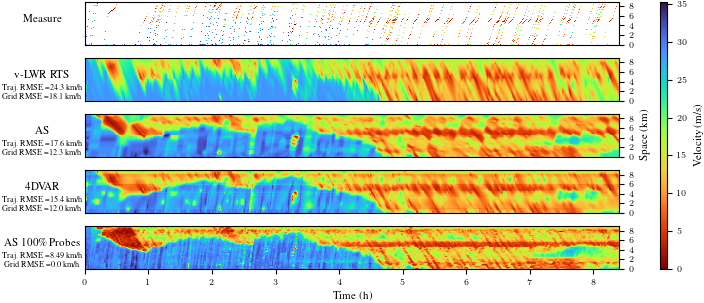

In [30]:
from matplotlib.ticker import MaxNLocator
from traffic_models.plot.utils import rcparams
from traffic_models.metrics import trajectory_mse

_rcparams = rcparams(fraction=1, subplots=(0.7, 1), beamer=False, ieee=True, columns=2)
plt.rcParams.update(_rcparams)
# plt.rcdefaults()
fig, axes = plt.subplots(5, 1)
vmin = 0 #min(fields.speed.min(), pred.v_hat.min(), measured_v.min())
vmax = max(fields.speed.max(), measured_v.max())
titles = ["Measure", "v-LWR RTS", "AS", "4DVAR", r"AS 100\% Probes"]
for ax, matrix, title in zip(axes, (measured_v, v_smooth, v_asm, v_smooth_4dvar, fields.speed), titles):
    t_slice_start = 0 # 500 #
    t_slice_end = grid.n_timesteps # 700 #
    ax.matshow(
        matrix[t_slice_start:t_slice_end].T,
        extent=(0, fields.tmax/3600, 0, fields.xmax/1000),
        vmin=vmin,
        vmax=vmax,
        origin="lower",
        aspect="auto",
        cmap="turbo_r"
    )
    ax.xaxis.set_ticks_position("bottom")
    ax.xaxis.set_label_position("bottom")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.get_xaxis().set_visible(False)
    # hidden_trajectories = full_trajectories.remove(pl.col.vehicle_id.is_in(discretized_trajectories["vehicle_id"]))
    mse = trajectory_mse(full_trajectories, matrix)
    grid_mse = ((matrix - fields.speed) ** 2).mean()
    score_text = f"Traj. RMSE ={mse**0.5*3.6:.3} km/h\n Grid RMSE ={grid_mse**0.5*3.6:.3} km/h" if title!="Measure" else ""
    ax.text(-0.08, 0.6, title, transform=ax.transAxes, va='center', ha='center')
    ax.text(-0.08, 0.2, score_text, transform=ax.transAxes, va='center', ha='center', fontsize=6)
    # ax.title.set_fontsize(10)
axes[-1].set_xlabel("Time (h)")
axes[-1].get_xaxis().set_visible(True)
fig.text(1.04, 0.5, "Space (km)", transform=axes[2].transAxes, rotation=90, va='center', ha='left')
axes[2].yaxis.set_label_position("right")

cbar = fig.colorbar(
    axes[0].images[0],
    ax=axes,
    label="Velocity (m/s)",
    orientation="vertical",
    aspect=40,
    location='right',
    # shrink=0.45
);
plt.savefig(
    f"output_plots/itsc/{conf.data.name}_comparison_plot_pwq_with_grid_mse.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
);


# PINN Training

In [ ]:
from traffic_models.pinn import PINNConfig, train_pinn
from traffic_models.flows import ARZFlow, PiecewiseQuadraticFlow
from traffic_models.metrics import trajectory_mse

pinn_flow = ARZFlow(PiecewiseQuadraticFlow(v_max=40, rho_max=0.22, rho_c=0.03, Q_max=0.8))
pinn_flow = ARZFlow(PowerLawFlux(v_max=40, rho_max=0.15, gamma=1.0))
pinn_result = train_pinn(
    trajectories=discretized_trajectories,
    grid=grid,
    flow=pinn_flow,
    conf=PINNConfig(
        n_collocation=150_000,
        epochs=50_500,
        n_epochs_adam=50_000,
        lr=1e-3,
        observation_weight=1.0,
        physics_weight=0.0,
        log_every=500,
        learn_flow=False,
    ),
    device="cuda" if torch.cuda.is_available() else "cpu",
)
mse = trajectory_mse(full_trajectories, pinn_result.velocity_hat)
print(f"PINN RMSE: {mse**0.5*3.6:.2f} kmph")

fig, axes = plt.subplots(3, 1)
axes[0].matshow(pinn_result.rho_hat.T, aspect="auto", origin="lower", cmap="turbo")
axes[0].set_title("PINN Density")
axes[1].matshow(pinn_result.velocity_hat.T, aspect="auto", origin="lower", cmap="turbo_r", vmin=0, vmax=35)
axes[1].set_title("PINN Velocity")
axes[2].matshow(fields.speed.T, aspect="auto", origin="lower", cmap="turbo_r", vmin=0, vmax=35)
axes[2].set_title("True Speed")
plt.tight_layout()

# EnKF

EnKF RMSE: 26.77 kmph


/home/julien_moreau_renault_com/traffic-models/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/julien_moreau_renault_com/traffic-models/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


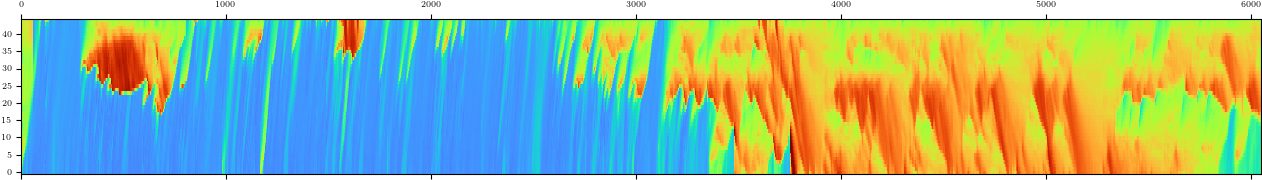

In [ ]:
from traffic_models.extended_kalman import run_enkf_on_trajectories
from traffic_models.flows import ZeroFlow
flow = triangular_mobile_century_herrera_bayen_2010()
flow = greenshields_mobile_century_herrera_bayen_2010()
v_enkf = run_enkf_on_trajectories(
    discretized_trajectories=discretized_trajectories,
    P_0=INIT_MODEL_VARIANCE * np.eye(grid.n_cells),
    v_0=fields.speed.mean(),
    flow=flow,
    Q=conf.kalman.velocity_model_variance * np.eye(grid.n_cells),
    VELOCITY_MEASURE_VARIANCE=VELOCITY_MEASURE_VARIANCE,
    grid=grid,
)
plt.matshow(v_enkf.T, aspect="auto", origin="lower",cmap="turbo_r", vmin=0, vmax=35)
print(f"EnKF RMSE: {(trajectory_mse(full_trajectories, v_enkf)**0.5)*3.6:.2f} kmph")

# EnKF with sources

In [ ]:
from traffic_models.extended_kalman import run_ctm_enkf_on_trajectories
# flow = triangular_mobile_century_herrera_bayen_2010()
flow = greenshields_mobile_century_herrera_bayen_2010()
Q = np.diag(np.concatenate((
    conf.kalman.velocity_model_variance*np.ones(grid.n_cells),
    0.1* np.ones(len(on_ramps_index)+len(off_ramps_index))
)))
P_0 = np.diag(np.concatenate((
    INIT_MODEL_VARIANCE * np.ones(grid.n_cells),
    1.0 * np.ones(len(on_ramps_index)+len(off_ramps_index))
)))
v_enkf = run_ctm_enkf_on_trajectories(
    discretized_trajectories=discretized_trajectories,
    P_0=P_0,
    v_0=fields.speed.mean(),
    flow=flow,
    Q=Q,
    VELOCITY_MEASURE_VARIANCE=VELOCITY_MEASURE_VARIANCE,
    grid=grid,
    ramp_index=np.concatenate([on_ramps_index, off_ramps_index]),
    n_particles=30,

)
plt.matshow(v_enkf.T, aspect="auto", origin="lower",cmap="turbo_r", vmin=0, vmax=35)
print(f"EnKF RMSE: {(trajectory_mse(full_trajectories, v_enkf)**0.5)*3.6:.2f} kmph")

## Creating an animation

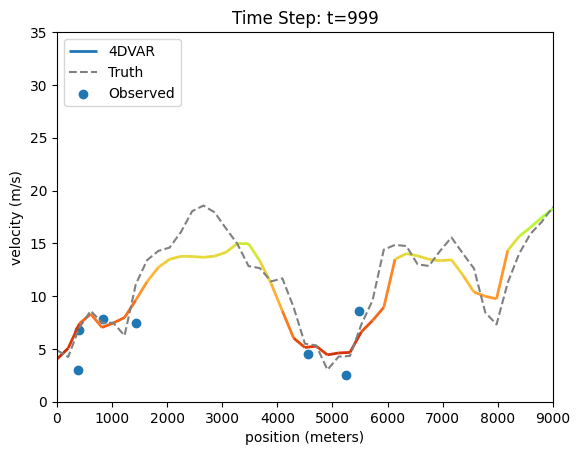

In [35]:
from matplotlib import animation
from matplotlib.collections import LineCollection
from scipy.ndimage import convolve1d

plt.style.use("default")
start_t = 3000
end_t = 4000
# end_t = 3100
TIME_SMOOTHING = 10
window = max(1, int(TIME_SMOOTHING / conf.dt_seconds))
kernel = np.ones(window) / window
smoothed_v = convolve1d(fields.speed, weights=kernel, axis=0, mode="nearest")

fig, ax = plt.subplots()
x_values = np.linspace(0, grid.n_cells * grid.dx_meters, v_smooth_4dvar.shape[1])


def _line_segments(x_data: np.ndarray, y_data: np.ndarray) -> np.ndarray:
    points = np.array([x_data, y_data]).T.reshape(-1, 1, 2)
    return np.concatenate([points[:-1], points[1:]], axis=1)


line_norm = plt.Normalize(vmin=0, vmax=35)
line_2 = LineCollection(
    _line_segments(x_values, v_smooth_4dvar[start_t]),
    cmap="turbo_r",
    norm=line_norm,
    linewidth=2,
    label="4DVAR",
)
line_2.set_array(v_smooth_4dvar[start_t][:-1])
ax.add_collection(line_2)
line_truth, = ax.plot(
    x_values,
    smoothed_v[start_t],
    linestyle="--",
    color="grey",
    linewidth=1.5,
    label="Truth",
)

x_values_at_t = discretized_trajectories.filter(t_index=start_t)["x_meters"]
v_values_at_t = discretized_trajectories.filter(t_index=start_t)["velocity"]
scatter = ax.scatter(x_values_at_t, v_values_at_t, label="Observed")

ax.set_xlim(x_values.min(), x_values.max())
ax.set_xlabel("position (meters)")
ax.set_ylabel("velocity (m/s)")
ax.set_ylim(0, 35)
ax.legend(loc="upper left")


def update(frame: int) -> None:
    y_values = v_smooth_4dvar[start_t + frame]
    line_2.set_segments(_line_segments(x_values, y_values))
    line_2.set_array(y_values[:-1])
    line_truth.set_ydata(smoothed_v[start_t + frame])

    SAMPLE_INTERVAL_SECONDS = 1
    trajectories_at_t = discretized_trajectories.filter(
        (start_t + frame - pl.col.t_index) > 0,
        (start_t + frame - pl.col.t_index) <= SAMPLE_INTERVAL_SECONDS,
        is_boundary_information=False,
    )
    x_values_at_t = trajectories_at_t["x_meters"]
    v_values_at_t = trajectories_at_t["velocity"]
    scatter.set_offsets(np.c_[x_values_at_t, v_values_at_t])
    ax.set_title(f"Time Step: t={frame}")


ani = animation.FuncAnimation(fig, update, frames=end_t - start_t, interval=30)
ani.save(f"output_plots/fourdvar_{conf.data.name}_20pc.gif", writer="pillow", fps=20)
plt.show()